In [1]:
import sys


from pyS3M import IOFunctions
from pyS3M import CalibrationFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import MaskFunctions

Mask = MaskFunctions.Mask_Functions()

from pyS3M import PlottingBase

import os
import matplotlib.pyplot as plt
import numpy as np

plotter = PlottingBase.PublicationPlotter()

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

/tmp/ipykernel_2627998/980287208.py:20: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


In [2]:
directory = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260403_ZWOCalibration/100_ms"

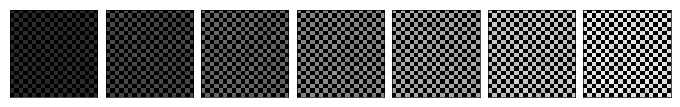

In [3]:
colour = "G"


file_H = "Intensity_07_MMStack_1.ome.tif"

data_H = IO.read_tiff(os.path.join(directory, colour, file_H), dtype=np.uint16, frame=1)
mosaic_unit = np.array([["R", "G"], ["G", "B"]])
masks = Mask.get_masks(
    mosaic_unit=mosaic_unit, size_x=data_H.shape[0], size_y=data_H.shape[1]
)
vmax = np.percentile(data_H, 99.9)
fig, axs = plotter.two_column_plot(ncolumns=7, widthratio=np.ones(7))

for i in np.arange(7):
    j = i+1
    filename = 'Intensity_'+str(j).zfill(2)+'_MMStack_1.ome.tif'
    data = IO.read_tiff(os.path.join(directory, colour, filename), dtype=np.uint16, frame=1)
    axs[i] = plotter.image_plot(
        axs=axs[i],
        data=np.array(data * masks[colour])[:20, :20],
        scalebarlabel="",
        scalebarsize=0,
        cbar=False,
        vmax=vmax,
    )


In [4]:
mosaic_unit = np.array([["R", "G"], ["G", "B"]])
C_F = CalibrationFunctions.Calibration_Functions(mosaic_unit=mosaic_unit)
offset, variance, gain, readnoise, rqe = C_F.calibrate_multicolour_camera(
    directory, imtype=".tif"
)

## Temporal frame-mean analysis
Check whether the excess variance in the B channel has a clear temporal signature —
e.g. a warm-up ramp at the start, or a per-file first-frame spike — that could be
removed by discarding a fixed number of frames.

In [ ]:
import re

# ── user parameters ────────────────────────────────────────────────────────────
N_FILES_TO_SAMPLE = 10   # number of files to read per (colour, intensity) pair
#   set to None to read all files (slow – ~30 k frames per combination)
COLOURS_TO_PLOT   = ["R", "G", "B"]
INTENSITIES       = [f"Intensity_{str(i).zfill(2)}" for i in range(1, 8)]
# ──────────────────────────────────────────────────────────────────────────────


def sorted_intensity_files(directory, intensity_prefix):
    """Return files matching intensity_prefix, sorted by their trailing integer.
    The file without a trailing number (MMStack.ome.tif) sorts first (index 0)."""
    files = [f for f in os.listdir(directory)
             if f.startswith(intensity_prefix) and f.endswith(".tif")]
    def _key(f):
        m = re.search(r'MMStack_(\d+)\.ome\.tif$', f)
        return int(m.group(1)) if m else 0
    return sorted(files, key=_key)


# Build masks once from the dark offset image (already computed above)
masks = Mask.get_masks(
    mosaic_unit=mosaic_unit,
    size_x=offset.shape[0],
    size_y=offset.shape[1],
)

# ── collect temporal traces ────────────────────────────────────────────────────
# traces[colour][intensity] = 1-D array of per-frame means (colour pixels only)
# file_boundaries[colour][intensity] = list of frame indices where a new file starts
traces = {c: {} for c in COLOURS_TO_PLOT}
file_boundaries = {c: {} for c in COLOURS_TO_PLOT}

for colour in COLOURS_TO_PLOT:
    colour_dir = os.path.join(directory, colour)
    m = masks[colour]

    for intensity in INTENSITIES:
        files = sorted_intensity_files(colour_dir, intensity)
        if N_FILES_TO_SAMPLE is not None:
            files = files[:N_FILES_TO_SAMPLE]

        means = []
        boundaries = [0]

        for fname in files:
            path = os.path.join(colour_dir, fname)
            n_frames = IO.get_n_frames(path)
            chunk = IO.read_tiff(path, frame=list(range(n_frames)))
            if chunk.ndim == 2:
                chunk = chunk[np.newaxis]   # (1, H, W)
            # per-frame mean over colour pixels
            frame_means = chunk[:, m].mean(axis=1)   # (n_frames,)
            means.append(frame_means)
            boundaries.append(boundaries[-1] + n_frames)

        traces[colour][intensity] = np.concatenate(means)
        file_boundaries[colour][intensity] = boundaries[:-1]   # start indices only

print("Temporal traces collected.")
for colour in COLOURS_TO_PLOT:
    ex = traces[colour][INTENSITIES[0]]
    print(f"  {colour} Intensity_01: {len(ex)} frames,  "
          f"mean={ex.mean():.1f},  std={ex.std():.2f},  "
          f"min={ex.min():.1f},  max={ex.max():.1f}")

In [ ]:
# ── Plot 1: full temporal trace per colour, one line per intensity ─────────────
# Each panel shows the raw per-frame mean.  File-boundary frames are marked with
# vertical dashed lines so you can see if the first frame of each file is a spike.

colour_map = {"R": "tab:red", "G": "tab:green", "B": "tab:blue"}
n_colours  = len(COLOURS_TO_PLOT)

fig, axs = plt.subplots(n_colours, 1, figsize=(14, 3.5 * n_colours), sharex=False)
if n_colours == 1:
    axs = [axs]

for ax, colour in zip(axs, COLOURS_TO_PLOT):
    base_colour = colour_map[colour]
    alphas = np.linspace(0.4, 1.0, len(INTENSITIES))

    for alpha, intensity in zip(alphas, INTENSITIES):
        trace = traces[colour][intensity]
        t     = np.arange(len(trace))
        ax.plot(t, trace, color=base_colour, alpha=alpha, lw=0.6,
                label=intensity.replace("Intensity_", "step "))

        # mark file boundaries
        for b in file_boundaries[colour][intensity]:
            ax.axvline(b, color="k", lw=0.4, alpha=0.25, zorder=0)

    ax.set_ylabel("Mean pixel value (ADU)")
    ax.set_xlabel("Frame index")
    ax.set_title(f"{colour} channel — temporal mean of {colour} pixels\n"
                 f"(vertical lines = start of each new .tif file)")
    ax.legend(fontsize=7, ncol=len(INTENSITIES), loc="upper right")

fig.suptitle("Temporal frame-mean traces — first {:d} files per (colour, intensity)".format(
    N_FILES_TO_SAMPLE if N_FILES_TO_SAMPLE is not None else 999), y=1.01)
fig.tight_layout()
plt.show()

# ── Plot 2: zoom on first file only — first-frame spike check ─────────────────
fig2, axs2 = plt.subplots(1, n_colours, figsize=(5 * n_colours, 3.5), sharey=False)
if n_colours == 1:
    axs2 = [axs2]

for ax, colour in zip(axs2, COLOURS_TO_PLOT):
    base_colour = colour_map[colour]
    for alpha, intensity in zip(alphas, INTENSITIES):
        trace = traces[colour][intensity]
        n_show = min(30, len(trace))          # first 30 frames
        ax.plot(np.arange(n_show), trace[:n_show],
                "o-", ms=3, lw=0.8, color=base_colour, alpha=alpha,
                label=intensity.replace("Intensity_", "step "))
    ax.axvline(0.5, color="k", lw=1, ls="--", label="after frame 0")
    ax.set_xlabel("Frame index")
    ax.set_ylabel("Mean pixel value (ADU)")
    ax.set_title(f"{colour}: first 30 frames of first file")
    ax.legend(fontsize=7, ncol=2)

fig2.suptitle("First-frame effect check (is frame 0 anomalous?)")
fig2.tight_layout()
plt.show()

# ── Summary: first-frame excess vs rest ───────────────────────────────────────
print("First-frame excess (frame 0 mean − frames 1+ mean), per colour per intensity:")
for colour in COLOURS_TO_PLOT:
    for intensity in INTENSITIES:
        trace = traces[colour][intensity]
        excess = trace[0] - trace[1:].mean()
        print(f"  {colour} {intensity}: {excess:+.2f} ADU")